In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

from umap import UMAP
import trimap
import pacmap

%matplotlib inline

In [19]:
nb_classes = 10
dropout = 0.5

# Build very simple neural network with 2 hidden layers
model = Sequential(
    [
        Input(shape=(784,)),
        Dense(256, activation="relu"),
        Dropout(dropout),
        Dense(64, activation="relu"),
        Dropout(dropout),
        Dense(nb_classes, activation="softmax"),
    ]
)


model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

Fashion-MNIST ma identyczny format jak MNIST (60000 treningowych + 10000 testowych obrazów 28×28 w skali szarości, 10 klas), ale klasy to: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot. Niektóre z nich (T-shirt/Shirt/Pullover/Coat) są wizualnie bardzo podobne - i to jest źródło głównej trudności tego zbioru, zbiór ten jest znacznie bardziej złożony.

In [20]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Put everything on grayscale
X_train /= 255
X_test /= 255

# Convert class vectors to binary class matrices
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

# Split training and validation data
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, train_size=5 / 6)

In [21]:
network_history = model.fit(
    X_train,
    Y_train,
    batch_size=128,
    epochs=20,
    verbose=1,
    validation_data=(X_val, Y_val),
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6976 - loss: 0.8522 - val_accuracy: 0.8200 - val_loss: 0.4928
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8010 - loss: 0.5656 - val_accuracy: 0.8472 - val_loss: 0.4268
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8248 - loss: 0.4993 - val_accuracy: 0.8525 - val_loss: 0.4044
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8362 - loss: 0.4653 - val_accuracy: 0.8584 - val_loss: 0.3950
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8402 - loss: 0.4499 - val_accuracy: 0.8660 - val_loss: 0.3801
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8481 - loss: 0.4294 - val_accuracy: 0.8650 - val_loss: 0.3686
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8495 - loss: 0.4237 - val_accuracy: 0.8663 - val_loss: 0.3638
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8524 - loss: 0.4136 - val_accuracy: 0.

In [22]:
def plot_history(network_history):
    plt.figure()
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.plot(network_history.history["loss"])
    plt.plot(network_history.history["val_loss"])
    plt.legend(["Training", "Validation"])

    plt.figure()
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.plot(network_history.history["accuracy"])
    plt.plot(network_history.history["val_accuracy"])
    plt.legend(["Training", "Validation"], loc="lower right")
    plt.show()

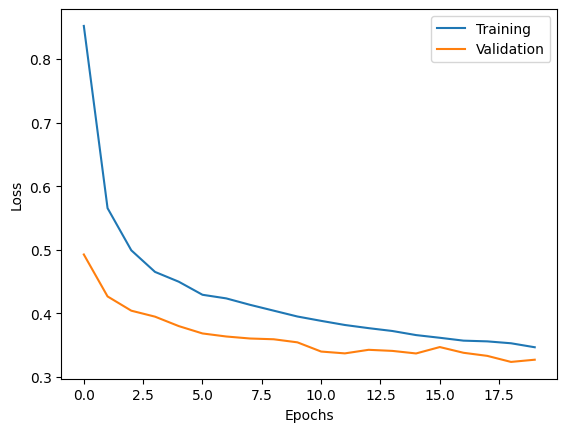

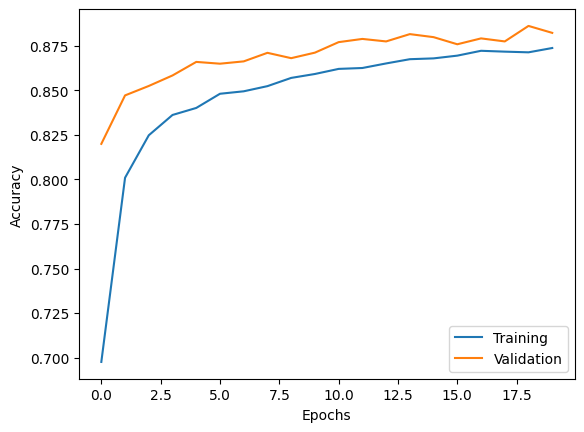

In [23]:
plot_history(network_history)

Krzywe walidacyjne wypłaszczają się dużo wcześniej i niżej niż w MNIST - sieć szybko trafia na sufit ~88% accuracy i dalej nie poprawia wyników. To bezpośrednia konsekwencja podobieństwa klas: część próbek jest po prostu niemożliwa do jednoznacznego sklasyfikowania na podstawie samych pikseli (nawet człowiekowi sprawia to trudność).

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,176 (2.50 MB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436,118 (1.66 MB)

## Ekstrakcja warstw

Wyodrębniam wyjścia warstw `Dense` z wytrenowanej sieci. Sequential w Keras 3 nie udostępnia bezpośrednio `.input` i `.output`, więc budujemy nowy model przepuszczając `Input` przez te same (już wytrenowane) warstwy. W liście `intermediate` będziemy mieć referencje do warstw ukrytych `Dense`.

In [25]:
inp = Input(shape=(784,))
x = inp
intermediate = []
for layer in model.layers:
    x = layer(x)
    if isinstance(layer, Dense):
        intermediate.append(x)

layer_outputs_model = Model(inputs=inp, outputs=intermediate)
print(f"Outputs captured: {len(intermediate)}")

Outputs captured: 3


## Fashion-MNIST, podział na zbiory

Podpróbka 5000 treningowych + 2000 testowych, jak w MNIST. Pobieram aktywacje h1 (256D) i h2 (64D) dla obu zbiorów.

In [26]:
N_TRAIN = 5000
N_TEST = 2000
rng = np.random.default_rng(42)

y_train_int = np.argmax(Y_train, axis=1)
y_test_int = np.argmax(Y_test, axis=1)

idx_train = rng.choice(len(X_train), N_TRAIN, replace=False)
idx_test = rng.choice(len(X_test), N_TEST, replace=False)

X_tr, y_tr = X_train[idx_train], y_train_int[idx_train]
X_te, y_te = X_test[idx_test], y_test_int[idx_test]

h1_tr, h2_tr, _ = layer_outputs_model(X_tr, training=False)
h1_te, h2_te, _ = layer_outputs_model(X_te, training=False)

h1_tr, h2_tr = h1_tr.numpy(), h2_tr.numpy()
h1_te, h2_te = h1_te.numpy(), h2_te.numpy()

print(f"Train: X={X_tr.shape}, h1={h1_tr.shape}, h2={h2_tr.shape}")
print(f"Test : X={X_te.shape}, h1={h1_te.shape}, h2={h2_te.shape}")

Train: X=(5000, 784), h1=(5000, 256), h2=(5000, 64)
Test : X=(2000, 784), h1=(2000, 256), h2=(2000, 64)


## Pomocnicze funkcje wizualizacji + nazwy klas

Dodaję listę `FASHION_CLASSES` z czytelnymi nazwami klas.

In [27]:
FASHION_CLASSES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

PAL = np.array(sns.color_palette("tab10", 10))


def scatter_emb(ax, emb, labels, title):
    for c in range(10):
        mask = labels == c
        ax.scatter(emb[mask, 0], emb[mask, 1], s=1.5, alpha=0.55, color=PAL[c])
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])


def add_legend(fig, names=FASHION_CLASSES, ncol=5):
    patches = [mpl.patches.Patch(color=PAL[i], label=names[i]) for i in range(10)]
    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=ncol,
        fontsize=8,
        bbox_to_anchor=(0.5, -0.02),
    )

## Redukcja wymiarowości danych treningowych

Stosuję cztery metody (t-SNE, UMAP, TriMAP, PaCMAP) do trzech wejść: surowych pikseli, aktywacji pierwszej warstwy ukrytej i aktywacji drugiej warstwy ukrytej. Modele UMAP zachowuję, żeby później rzutować nimi dane testowe (ponieważ tylko UMAP może być ponownie użyty do transformacji nowych punktów bez ponownego trenowania).

In [28]:
inputs_tr = {"raw": X_tr, "h1": h1_tr, "h2": h2_tr}
sources = ["raw", "h1", "h2"]
methods = ["t-SNE", "UMAP", "TriMAP", "PaCMAP"]

embeddings_tr = {}
umap_models = {}

for src, data in inputs_tr.items():
    print(f"--- {src} ---")

    embeddings_tr[(src, "t-SNE")] = TSNE(n_components=2, random_state=42).fit_transform(
        data
    )
    print("t-SNE done")

    umap_m = UMAP(n_components=2, random_state=42)
    embeddings_tr[(src, "UMAP")] = umap_m.fit_transform(data)
    umap_models[src] = umap_m
    print("UMAP done")

    embeddings_tr[(src, "TriMAP")] = trimap.TRIMAP().fit_transform(data)
    print("TriMAP done")

    embeddings_tr[(src, "PaCMAP")] = pacmap.PaCMAP(n_components=2).fit_transform(data)
    print("PaCMAP done")

--- raw ---
t-SNE done


C:\Users\Filip\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done
TriMAP done
PaCMAP done
--- h1 ---
t-SNE done


C:\Users\Filip\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done
TriMAP done
PaCMAP done
--- h2 ---
t-SNE done


C:\Users\Filip\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done
TriMAP done
PaCMAP done


## Krok 3: Wizualizacja embeddingów - dane treningowe

Siatka 3×4: wiersze to źródło wejścia (surowe piksele, hidden 1, hidden 2), kolumny to metoda redukcji.

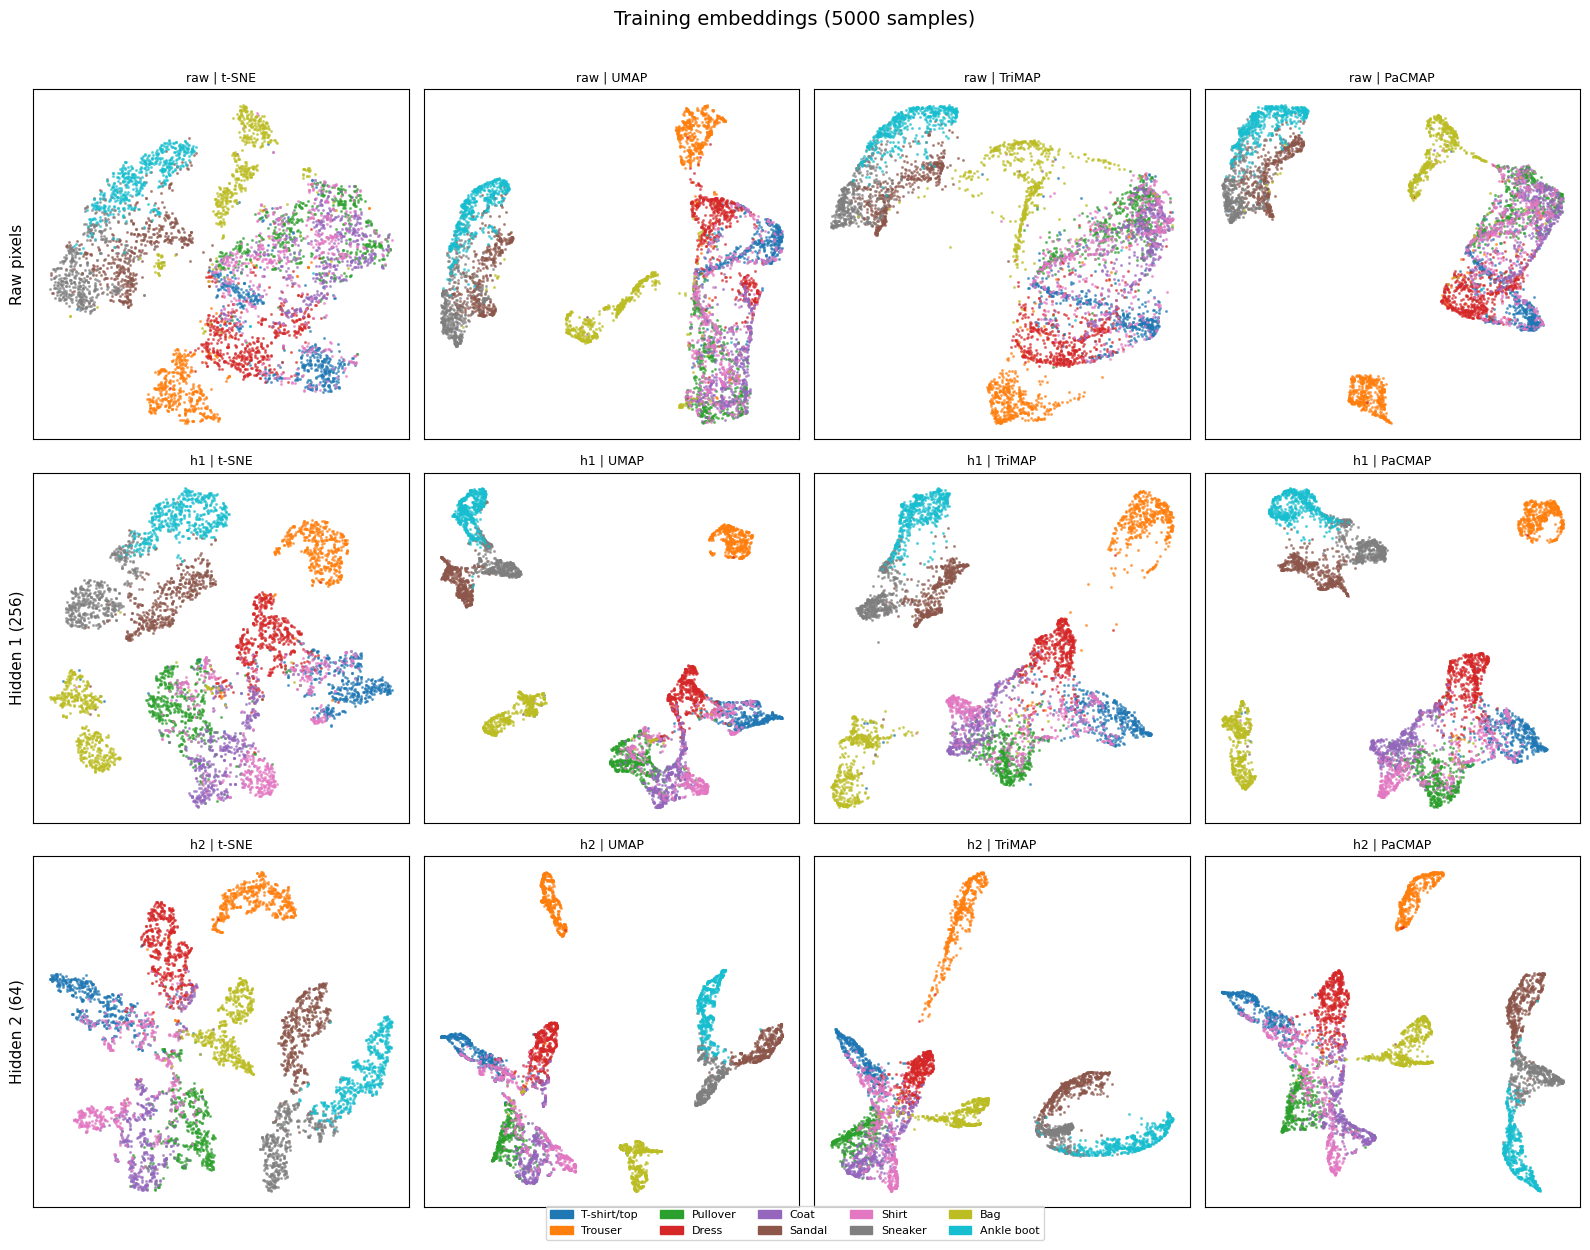

In [29]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

row_labels = {"raw": "Raw pixels", "h1": "Hidden 1 (256)", "h2": "Hidden 2 (64)"}

for r, src in enumerate(sources):
    for c, m in enumerate(methods):
        scatter_emb(axes[r, c], embeddings_tr[(src, m)], y_tr, f"{src} | {m}")
    axes[r, 0].set_ylabel(row_labels[src], fontsize=11, labelpad=6)

fig.suptitle("Training embeddings (5000 samples)", fontsize=14, y=1.01)
add_legend(fig)
plt.tight_layout()
plt.show()

W odróżnieniu od MNIST, klastry Fashion-MNIST nakładają się znacznie częściej, zwłaszcza na surowych pikselach. Dla h2 sytuacja się poprawia, chociaż niektóre klasy pozostają słabo rozdzielone nawet na warstwie h2. To sygnał, że sieć sama ma problem z tymi klasami.

## Projekcja danych testowych (UMAP)

t-SNE, TriMAP i PaCMAP są nieparametryczne - nie da się nimi rzutować nowych punktów na istniejący manifold. UMAP ma metodę `transform`, więc używam go do projekcji danych testowych. Modele UMAP zostały już dopasowane w poprzednim kroku (po jednym dla każdego źródła).

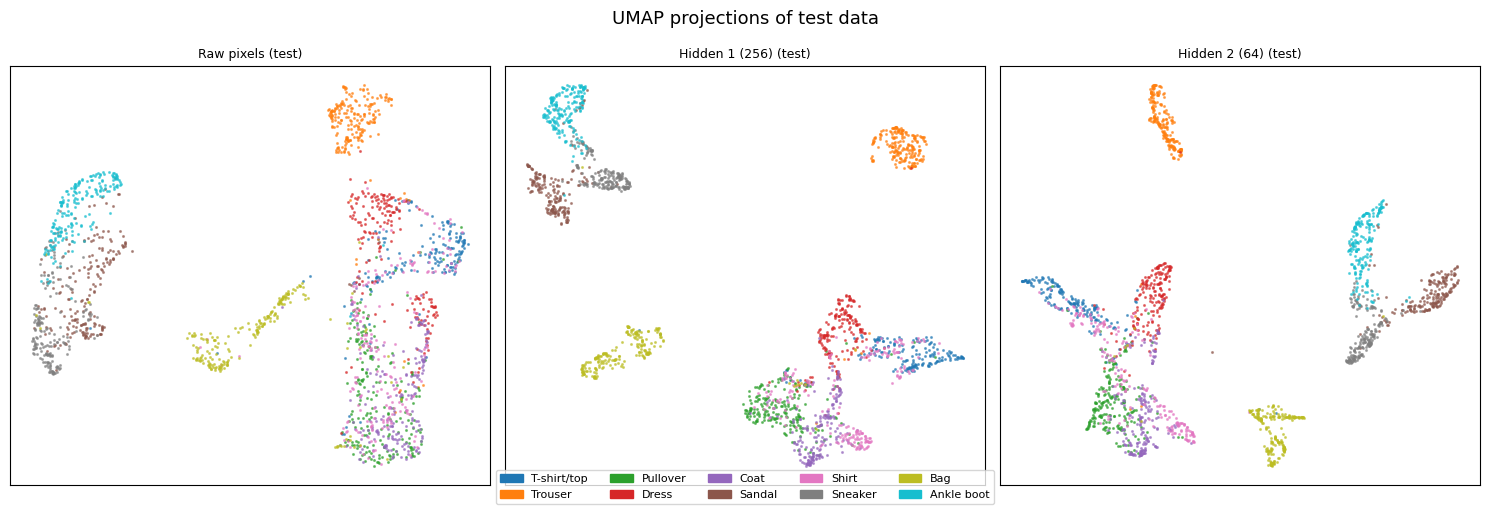

In [30]:
inputs_te = {"raw": X_te, "h1": h1_te, "h2": h2_te}

# for each layer, transform test data
embeddings_te_umap = {
    src: umap_models[src].transform(inputs_te[src]) for src in sources
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for c, src in enumerate(sources):
    scatter_emb(axes[c], embeddings_te_umap[src], y_te, f"{row_labels[src]} (test)")
fig.suptitle("UMAP projections of test data", fontsize=13)
add_legend(fig)
plt.tight_layout()
plt.show()

## Klasyfikacja kNN na embeddingach UMAP

Dla każdego źródła (raw / h1 / h2) trenuję kNN na 2D-embeddingach UMAP zbioru treningowego, a klasyfikuję 2D-projekcje zbioru testowego. Sprawdzam `n_neighbors` $\in$ {3, 5, 10}.

In [31]:
n_neighbors_list = [3, 5, 10]
records = []

for src in sources:
    X_emb_tr = embeddings_tr[(src, "UMAP")]
    X_emb_te = embeddings_te_umap[src]
    for k in n_neighbors_list:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_emb_tr, y_tr)
        acc = accuracy_score(y_te, knn.predict(X_emb_te))
        records.append({"input": src, "n_neighbors": k, "accuracy": round(acc, 4)})
        print(f"  {src:<4}  n_neighbors={k:>2}   accuracy={acc:.4f}")

df_results = pd.DataFrame(records)

  raw   n_neighbors= 3   accuracy=0.6990
  raw   n_neighbors= 5   accuracy=0.7145
  raw   n_neighbors=10   accuracy=0.7315
  h1    n_neighbors= 3   accuracy=0.8325
  h1    n_neighbors= 5   accuracy=0.8345
  h1    n_neighbors=10   accuracy=0.8400
  h2    n_neighbors= 3   accuracy=0.8295
  h2    n_neighbors= 5   accuracy=0.8470
  h2    n_neighbors=10   accuracy=0.8535


In [32]:
pivot = df_results.pivot(index="input", columns="n_neighbors", values="accuracy")
pivot = pivot.reindex(sources)
pivot.style.format("{:.4f}").background_gradient(cmap="RdYlGn", axis=None)

n_neighbors,3,5,10
input,,,
raw,0.6990,0.7145,0.7315
h1,0.8325,0.8345,0.8400
h2,0.8295,0.8470,0.8535


## Wnioski

Dokładność klasyfikacji **wciąż rośnie wraz z głębokością źródła**. Dokładność rośnie z 0.73 (piksele) przez 0.84 (h1) do 0.86 (h2), a duży skok (+13 pp) wynika z tego, że sieć zamienia surowe piksele ubrań na bardziej znaczące cechy jak kształt czy elementy odzieży, które lepiej rozróżniają klasy. Mimo większego boostu w punktach procentowych, ostateczna dokładność i tak nie dorównuje MNIST (~0.86 vs ~0.98). Sieć szybko trafia na "sufit" wynikający z samej natury zbioru.

Najlepsza dokładnosć została uzyskana dla warstwy h2 i liczby sąsiadów 10 i wyniosła 0.855. Różnice w wynikach między sąsiadami są już też zauważalne, choć nie wynoszą zbyt dużo, około 0.1 pp. Ponownie, separacja klas jest lepsza dla h2, niż dla raw data, ale i tak mamy zmieszane klastry. Najtrudniejszymi klasami do separacji okazały się górne części garderoby: t-shirty, bluzy, koszulki. Jest to dość logiczne - wyglądają podobnie, mamy odcienie szarości, piksele świecą się w podobnych miejscach. Najłatwiejsze to min. obuwie (sandal/sneaker).

Podsumowując, nawet h2 nie osiąga "sufitu" w okolicach dokładności sieci - ponieważ ten sufit jest już dużo niżej (~88% zamiast ~98% dla MNIST). Geometria klas w h2 jest tak dobra jak tylko może być przy danej trudności zbioru, ale po prostu niektóre klasy są fundamentalnie nieodróżnialne na podstawie samych pikseli.

---

MNIST ma wyraźnie lepiej odseparowane klasy, które tworzą zwarte i prawie całkowicie rozdzielone skupiska, natomiast w Fashion-MNIST większość klas jest widoczna, ale część (T-shirt, Pullover, Coat, Shirt) silnie się nakłada i tworzy wspólny, mieszany obszar.

**1. Jak reprezentacja ubrań przez sieć różni się od reprezentacji cyfr?**
Cyfry mają silne wzorce geometryczne (pętle, kreski, kąty), które sieć łatwo wykrywa już w warstwie h1. Ubrania to bardziej "tekstury i obrysy" - sylwetka, długość rękawa. Sieć musi pracować ciężej na bardziej rozproszonym sygnale, co ogranicza separowalność klas w h2. Dużo próbek jest bardzo podobnych do siecie. Tak jak już wspominałem wcześniej, ubrania takie, jak podkoszulki, koszulki, koszule są na tak małym obrazku często ciężkie do rozpoznania nawet przez człowieka. Sieć nie ma magicznej różdżki.

**2. Co tłumaczy różnice w jakości wizualizacji i klasyfikacji?**
Różnice wynikają głównie z tego, że klasy w F-MNIST są do siebie naturalnie podobne i częściowo się przenikają (np. shirt vs t-shirt, sneaker vs ankle boot), więc granice między nimi są nieostre; dlatego nawet dobrze działający model ma niższe maksimum skuteczności niż w MNIST, gdzie cyfry są bardziej jednoznaczne i lepiej separowalne.

**3. Która metoda redukcji wymiarowości najlepiej radzi sobie z F-MNIST i czy jest to ta sama, co dla MNIST?**
Dla MNIST najlepsze klastry dawały metody PaCMAP i UMAP. W przypadku FMNIST ciężko jest to powiedzieć, bo część klastrów zlewa się między sobą. Myślę, że ponownie PaCMAP i UMAP wypadają dość dobrze.

**4. Jak zmodyfikować architekturę sieci, żeby poprawić wizualizację/klasyfikację dla F-MNIST?**
Kilka kierunków:
- CNN zamiast MLP - Fashion-MNIST to obrazy; konwolucje mogą wychwycić cechy lokalne (krawędzie rękawa, tekstura) dużo lepiej niż w pełni połączone warstwy. To dałoby największą poprawę.
- Większa pojemność h2 - jeśli rozmaitości klas są bardziej splecione, większy wymiar h2 (np. 128 zamiast 64) dałby sieci więcej "miejsca", żeby je rozdzielić.
